# Static XAS — shot-resolved photon energy
Load per-shot (VLS, GMD) data produced by `compute_static_xas.py`.
Instead of using only the nominal step-motor photon energy, we assign each shot a **photon-energy proxy** from the centre-of-mass (COM) of its VLS spectrum, rounded to the nearest pixel integer. This shot-resolved proxy lets us sort the data more finely and increases the effective spectral resolution compared with nominal-energy binning alone.

**Background subtraction (done by `compute_static_xas.py` before writing the H5)**:
1. Per-train baseline: non-signal bunches (`BG_BUNCH_RANGE = 50–100`) subtracted per train.
2. Per-section closed-shutter reference: mean VLS of the preceding closed-shutter block is subtracted from each open-shutter section.

Both stages can leave negative pixel values. We clip to non-negative only for the COM, while keeping `A_valid` unmodified for downstream averaging.

Workflow:
1. Flatten all shots over `N_E` → `(N_shots_total, n_pixels)`.
2. Compute per-shot VLS COM (non-negative weights) → round to nearest pixel → proxy energy.
3. Bin shots by `(proxy_energy, GMD bin)`.
4. Make the same diagnostic plots with the proxy-pixel axis instead of nominal eV.

In [3]:
import os, sys
from pathlib import Path

os.environ["FLASH_ENV"] = "remote"

In [10]:
import sys
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
%matplotlib inline
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')
sys.path.insert(0, str(repo_root / 'analysis' / 'scripts'))
import config as path_config

from IPython.display import HTML, display

from scipy.signal import find_peaks, savgol_filter

## Config

In [5]:
RUN_NO   = 58793
INPUT_H5 = Path(path_config.COMBINED_DIR).parent / 'xas_static' / f'run{RUN_NO}_static_xas.h5'
# GMD bin edges (uJ).
GMD_EDGES = np.array([0.0,1.6, 3.2, 6.4, 12.8])
# VLS intensity threshold (per shot peak).
# Shots with max(VLS over pixels) < VLS_INTENSITY_THRESHOLD are removed.
# Set to None to disable this filter.
VLS_INTENSITY_THRESHOLD = 1000

## Load data

In [6]:
with h5py.File(INPUT_H5, 'r') as f:
    vls              = f['vls'][...]              # (N_E, N_shots_max, n_pixels)
    gmd              = f['gmd'][...]              # (N_E, N_shots_max)
    n_shots          = f['n_shots'][...]          # (N_E,)
    nominal_energies = f['nominal_energies'][...]  # (N_E,)  kept for reference
    vls_pixels       = f['vls_pixels'][...]        # (n_pixels,) pixel indices
    attrs            = dict(f.attrs)

N_E, N_shots_max, n_pixels = vls.shape
print(f'file       : {INPUT_H5}')
print(f'run        : {attrs.get("run_no")}')
print(f'shape      : N_E={N_E}, N_shots_max={N_shots_max}, n_pixels={n_pixels}')
print(f'total shots: {int(n_shots.sum())}')
print(f'VLS ROI    : {attrs.get("vls_crop_roi")}')

file       : /asap3/flash/gpfs/fl24/2026/data/11022188/processed/xas_static/run58793_static_xas.h5
run        : 58793
shape      : N_E=24, N_shots_max=37380, n_pixels=200
total shots: 838650
VLS ROI    : [450 650]


## Flatten and compute per-shot photon-energy proxy

All shots are pooled across N_E sections. For each shot the VLS
centre-of-mass is computed and rounded to the nearest pixel integer.
That integer is the **photon-energy proxy** (pixel → eV calibration will be added later).


`vls_pixels` stores absolute Gotthard pixel indices (450–649 for the 200-pixel ROI).The absolute pixel of proxy value `p` is `vls_pixels[p]`.
The COM is computed with relative indices 0…n_pixels-1 so the proxy stays in `[0, n_pixels)`.

In [7]:
# --- flatten ---
gmd_flat = gmd.reshape(-1)           # (N_E * N_shots_max,)
vls_flat = vls.reshape(-1, n_pixels)  # (N_E * N_shots_max, n_pixels)
nominal_energy_flat = np.repeat(nominal_energies, N_shots_max)  # (N_E * N_shots_max,)
# valid shots: finite GMD and finite VLS
ok = np.isfinite(gmd_flat) & np.all(np.isfinite(vls_flat), axis=1)
g_valid = gmd_flat[ok]              # (N_valid,)
A_valid = vls_flat[ok]              # (N_valid, n_pixels)
nominal_energy_valid = nominal_energy_flat[ok]  # (N_valid,)
print(f'valid shots (finite): {ok.sum()} / {ok.size}')
# --- optional VLS intensity threshold ---
peak_vls = np.nanmax(A_valid, axis=1)
if VLS_INTENSITY_THRESHOLD is not None:
    keep_peak = peak_vls >= VLS_INTENSITY_THRESHOLD
    removed = int((~keep_peak).sum())
    g_valid = g_valid[keep_peak]
    A_valid = A_valid[keep_peak]
    nominal_energy_valid = nominal_energy_valid[keep_peak]
    peak_vls = peak_vls[keep_peak]
    print(f'vls intensity threshold: removed {removed} shots with max(VLS) < {VLS_INTENSITY_THRESHOLD}')
else:
    print('vls intensity threshold: disabled (VLS_INTENSITY_THRESHOLD=None)')
# --- per-shot VLS COM -> proxy energy ---
# Use relative indices 0..n_pixels-1 so proxy_pixel stays in [0, n_pixels).
pix = np.arange(n_pixels, dtype=np.float64)  # (n_pixels,)
# Two rounds of background subtraction leave negative pixel values.
# Clip to non-negative for COM weights only; A_valid is kept intact for averaging.
A_pos = np.maximum(A_valid, 0.0)
A_sum_per_shot = A_pos.sum(axis=1)           # (N_valid,)
nonzero = A_sum_per_shot > 0
com_float = np.full(g_valid.size, np.nan)
com_float[nonzero] = (A_pos[nonzero] @ pix) / A_sum_per_shot[nonzero]
proxy_pixel = np.round(com_float).astype(np.int64)
# keep only shots with a well-defined COM
valid_com   = np.isfinite(com_float)
g_valid     = g_valid[valid_com]
A_valid     = A_valid[valid_com]
nominal_energy_valid = nominal_energy_valid[valid_com]
peak_vls    = peak_vls[valid_com]
proxy_pixel = proxy_pixel[valid_com]
print(f'shots with finite COM: {valid_com.sum()}')
print(f'proxy pixel range    : {proxy_pixel.min()} .. {proxy_pixel.max()}  '
      f'(absolute: {int(vls_pixels[proxy_pixel.min()])} .. {int(vls_pixels[proxy_pixel.max()])})')
print(f'nominal energy range : {nominal_energy_valid.min():.2f} .. {nominal_energy_valid.max():.2f} eV')
# sorted unique proxy energies
proxy_energies = np.sort(np.unique(proxy_pixel))   # (N_proxy_E,)
N_proxy_E      = len(proxy_energies)
print(f'unique proxy energies (pixels): {N_proxy_E}')
pixel_to_idx   = {int(p): i for i, p in enumerate(proxy_energies)}
proxy_idx      = np.array([pixel_to_idx[int(p)] for p in proxy_pixel], dtype=np.int64)

valid shots (finite): 838650 / 897120
vls intensity threshold: removed 206645 shots with max(VLS) < 1000
shots with finite COM: 632005
proxy pixel range    : 80 .. 141  (absolute: 530 .. 591)
nominal energy range : 270.00 .. 285.00 eV
unique proxy energies (pixels): 62


## Double-spike shots

### Pre-treatment of the data

In [11]:
# --- tunable parameters ---
SG_WINDOW = 9          # odd integer; light smoothing
SG_POLY = 2
BASELINE_Q = 0.15      # subtract low quantile as baseline per shot

MIN_DISTANCE_PX = 4    # minimum peak separation
MIN_PROM_SIGMA = 4.0   # peak prominence >= noise * this factor
MIN_HEIGHT_SIGMA = 3.0 # peak height above baseline >= noise * this factor
MIN_WIDTH_PX = 1.0
MAX_WIDTH_PX = 30.0

MIN_SECOND_RATIO = 0.20   # weaker peak >= this fraction of stronger peak
MAX_VALLEY_RATIO = 0.85   # valley / weaker_peak must be <= this
MAX_NPEAKS_KEEP = 4       # reject overly structured shots

TOP_N_PLOT = 18

In [12]:
def preprocess_shots_for_peakfinding(A, baseline_q=0.15, sg_window=9, sg_poly=2):
    """
    Baseline-correct and lightly smooth each shot.
    Returns:
        Xcorr : baseline-subtracted, clipped spectra
        Xsm   : smoothed spectra used for peak finding
        noise : robust per-shot noise estimate
    """
    X = np.asarray(A, dtype=np.float64)

    # baseline from low quantile of each shot
    baseline = np.quantile(X, baseline_q, axis=1, keepdims=True)
    Xcorr = X - baseline
    Xcorr[Xcorr < 0] = 0.0

    # savgol requires odd window and window > poly
    w = min(sg_window, Xcorr.shape[1] - (1 - Xcorr.shape[1] % 2))
    if w % 2 == 0:
        w -= 1
    if w <= sg_poly:
        w = sg_poly + 3 if (sg_poly + 3) % 2 == 1 else sg_poly + 4

    Xsm = savgol_filter(Xcorr, window_length=w, polyorder=sg_poly, axis=1, mode='interp')

    # robust noise estimate from first differences
    d = np.diff(Xcorr, axis=1)
    noise = 1.4826 * np.median(np.abs(d - np.median(d, axis=1, keepdims=True)), axis=1) / np.sqrt(2.0)

    # fallback for pathological zero-noise shots
    global_floor = np.median(noise[noise > 0]) if np.any(noise > 0) else 1.0
    noise = np.where(noise > 0, noise, global_floor)

    return Xcorr, Xsm, noise


def detect_double_spikes_findpeaks(
    Xcorr, Xsm, noise,
    min_distance_px=4,
    min_prom_sigma=4.0,
    min_height_sigma=3.0,
    min_width_px=1.0,
    max_width_px=30.0,
    min_second_ratio=0.20,
    max_valley_ratio=0.85,
    max_npeaks_keep=4,
):
    """
    Find candidate double-spike shots using scipy.signal.find_peaks.
    """
    nshots, npix = Xsm.shape

    is_double = np.zeros(nshots, dtype=bool)
    n_peaks = np.zeros(nshots, dtype=np.int16)
    peak1_px = np.full(nshots, -1, dtype=np.int16)
    peak2_px = np.full(nshots, -1, dtype=np.int16)
    peak1_h = np.full(nshots, np.nan, dtype=np.float32)
    peak2_h = np.full(nshots, np.nan, dtype=np.float32)
    prom1 = np.full(nshots, np.nan, dtype=np.float32)
    prom2 = np.full(nshots, np.nan, dtype=np.float32)
    valley_ratio = np.full(nshots, np.nan, dtype=np.float32)
    score = np.full(nshots, -np.inf, dtype=np.float32)

    for i in range(nshots):
        y = Xsm[i]
        sigma = noise[i]

        peaks, props = find_peaks(
            y,
            distance=min_distance_px,
            prominence=min_prom_sigma * sigma,
            height=min_height_sigma * sigma,
            width=(min_width_px, max_width_px),
        )

        n_peaks[i] = len(peaks)
        if len(peaks) < 2 or len(peaks) > max_npeaks_keep:
            continue

        # choose the two most prominent peaks, not just tallest
        order = np.argsort(props["prominences"])[::-1]
        peaks = peaks[order]
        prominences = props["prominences"][order]
        heights = props["peak_heights"][order]

        p1, p2 = peaks[:2]
        h1, h2 = heights[:2]
        pr1, pr2 = prominences[:2]

        # sort left-to-right for valley test
        if p2 < p1:
            p1, p2 = p2, p1
            h1, h2 = h2, h1
            pr1, pr2 = pr2, pr1

        weaker = min(h1, h2)
        stronger = max(h1, h2)
        if stronger <= 0 or weaker <= 0:
            continue

        valley = np.min(y[p1:p2 + 1])
        vr = valley / weaker
        sr = weaker / stronger

        if sr < min_second_ratio:
            continue
        if vr > max_valley_ratio:
            continue

        is_double[i] = True
        peak1_px[i] = p1
        peak2_px[i] = p2
        peak1_h[i] = h1
        peak2_h[i] = h2
        prom1[i] = pr1
        prom2[i] = pr2
        valley_ratio[i] = vr

        # score: reward strong/prominent second peak and deep valley
        score[i] = (min(pr1, pr2) / sigma) * (1.0 - vr) * sr

    return {
        "is_double": is_double,
        "n_peaks": n_peaks,
        "peak1_px": peak1_px,
        "peak2_px": peak2_px,
        "peak1_h": peak1_h,
        "peak2_h": peak2_h,
        "prom1": prom1,
        "prom2": prom2,
        "valley_ratio": valley_ratio,
        "score": score,
    }

In [13]:
Xcorr, Xsm, noise = preprocess_shots_for_peakfinding(
    A_valid,
    baseline_q=BASELINE_Q,
    sg_window=SG_WINDOW,
    sg_poly=SG_POLY,
)

### Peak finding

In [14]:
# --- Pair-scan detector with shot-relative peak-height floor ---

def detect_double_spikes_pairscan(
    Xcorr, Xsm, noise, proxy_pixel=None,
    min_distance_px=3,
    max_distance_px=17,
    min_prom_sigma=2.5,
    min_height_sigma=2.0,
    min_rel_peak_height=0.50,   # NEW: peaks must be >= this fraction of shot max
    min_width_px=1.0,
    max_width_px=40.0,
    min_second_ratio=0.05,
    min_bridge_drop=0.015,
    min_split_sigma=0.75,
    max_peaks_to_score=20,
    proxy_weight=0.10,
):
    nshots, npix = Xsm.shape

    is_candidate = np.zeros(nshots, dtype=bool)
    peak1_px = np.full(nshots, -1, dtype=np.int16)
    peak2_px = np.full(nshots, -1, dtype=np.int16)
    second_ratio = np.full(nshots, np.nan)
    valley_ratio = np.full(nshots, np.nan)
    bridge_drop = np.full(nshots, np.nan)
    split_sigma = np.full(nshots, np.nan)
    sep = np.full(nshots, np.nan)
    score = np.full(nshots, -np.inf)
    n_peaks = np.zeros(nshots, dtype=np.int16)

    for i in range(nshots):
        y = Xsm[i]
        sig = max(float(noise[i]), 1e-9)

        shot_max = np.nanmax(y)
        if not np.isfinite(shot_max) or shot_max <= 0:
            continue

        # Require peaks to clear both a noise-relative and shot-relative threshold.
        height_floor = max(
            min_height_sigma * sig,
            min_rel_peak_height * shot_max,
        )

        peaks, props = find_peaks(
            y,
            distance=min_distance_px,
            prominence=min_prom_sigma * sig,
            height=height_floor,
            width=(min_width_px, max_width_px),
        )

        n_peaks[i] = len(peaks)
        if len(peaks) < 2:
            continue

        order = np.argsort(props["prominences"])[::-1][:max_peaks_to_score]
        peaks = peaks[order]
        heights = props["peak_heights"][order]
        prominences = props["prominences"][order]

        best = None

        for a in range(len(peaks)):
            for b in range(a + 1, len(peaks)):
                p1, p2 = int(peaks[a]), int(peaks[b])
                h1, h2 = float(heights[a]), float(heights[b])
                pr1, pr2 = float(prominences[a]), float(prominences[b])

                lo, hi = sorted((p1, p2))
                s = hi - lo
                if s < min_distance_px or s > max_distance_px:
                    continue

                weaker = min(h1, h2)
                stronger = max(h1, h2)
                if weaker <= 0 or stronger <= 0:
                    continue

                valley = float(np.min(y[lo:hi + 1]))

                sr = weaker / stronger
                vr = valley / weaker
                bd = max((weaker - valley) / weaker, 0.0)
                ss = max((weaker - valley) / sig, 0.0)

                proxy_bonus = 1.0
                if proxy_pixel is not None:
                    inside = lo <= proxy_pixel[i] <= hi
                    proxy_bonus += proxy_weight * float(inside)

                sc = (
                    np.sqrt(max(min(pr1, pr2) / sig, 1e-6))
                    * np.sqrt(max(s, 1))
                    * sr
                    * (0.05 + bd)
                    * (1.0 + 0.20 * ss)
                    * proxy_bonus
                )

                if best is None or sc > best[0]:
                    best = (sc, lo, hi, sr, vr, bd, ss, s)

        if best is None:
            continue

        sc, lo, hi, sr, vr, bd, ss, s = best

        peak1_px[i] = lo
        peak2_px[i] = hi
        second_ratio[i] = sr
        valley_ratio[i] = vr
        bridge_drop[i] = bd
        split_sigma[i] = ss
        sep[i] = s
        score[i] = sc

        is_candidate[i] = (
            (sr >= min_second_ratio)
            and ((bd >= min_bridge_drop) or (ss >= min_split_sigma))
        )

    return dict(
        is_candidate=is_candidate,
        peak1_px=peak1_px,
        peak2_px=peak2_px,
        second_ratio=second_ratio,
        valley_ratio=valley_ratio,
        bridge_drop=bridge_drop,
        split_sigma=split_sigma,
        sep=sep,
        score=score,
        n_peaks=n_peaks,
    )

ds_pairscan = detect_double_spikes_pairscan(
    Xcorr, Xsm, noise,
    proxy_pixel=proxy_pixel,
    min_distance_px=3,
    max_distance_px=17,
    min_prom_sigma=2.5,
    min_height_sigma=2.0,
    min_rel_peak_height=0.35,  
    min_second_ratio=0.05,
    min_bridge_drop=0.015,
    min_split_sigma=0.75,
)

pairscan_idx = np.flatnonzero(ds_pairscan["is_candidate"])

print(f"pair-scan candidates: {len(pairscan_idx)} / {len(A_valid)} "
      f"= {len(pairscan_idx) / len(A_valid):.4%}")
print(f"shots with >=2 peaks found: {(ds_pairscan['n_peaks'] >= 2).sum()}")

if len(pairscan_idx) > 0:
    print(f"accepted separation range: "
          f"{np.nanmin(ds_pairscan['sep'][pairscan_idx]):.0f} .. "
          f"{np.nanmax(ds_pairscan['sep'][pairscan_idx]):.0f} px")

pair-scan candidates: 36 / 632005 = 0.0057%
shots with >=2 peaks found: 36
accepted separation range: 7 .. 11 px


In [16]:
def plot_double_spike_candidate_pages(
    indices,
    ds,
    n_per_page=36,
    ncols=6,
    max_pages=8,
    use_smoothed=True,
):
    indices = np.asarray(indices, dtype=int)
    nshow = min(len(indices), n_per_page * max_pages)
    indices = indices[:nshow]

    if len(indices) == 0:
        print("No accepted candidates to plot.")
        return

    x = np.arange(n_pixels)
    nrows = int(np.ceil(n_per_page / ncols))

    for start in range(0, len(indices), n_per_page):
        page = indices[start:start + n_per_page]

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(2.9 * ncols, 2.45 * nrows),
            sharex=True,
            squeeze=False,
        )

        for ax, idx in zip(axes.ravel(), page):
            y_raw = Xcorr[idx]
            y_sm = Xsm[idx]

            p1 = int(ds["peak1_px"][idx])
            p2 = int(ds["peak2_px"][idx])
            lo, hi = sorted((p1, p2))

            ax.plot(x, y_raw, color="0.75", lw=0.8, label="corrected")
            if use_smoothed:
                ax.plot(x, y_sm, color="k", lw=1.1, label="smoothed")

            if p1 >= 0 and p2 >= 0:
                ax.axvline(p1, color="tab:red", lw=0.9)
                ax.axvline(p2, color="tab:blue", lw=0.9)

                if hi > lo:
                    valley_x = lo + np.argmin(y_sm[lo:hi + 1])
                    ax.plot(
                        valley_x,
                        y_sm[valley_x],
                        "o",
                        color="tab:orange",
                        ms=3,
                    )

            ax.axvline(proxy_pixel[idx], color="tab:green", lw=0.8, ls="--")

            sr = ds["second_ratio"][idx]
            vr = ds["valley_ratio"][idx]
            bd = ds.get("bridge_drop", np.full(len(A_valid), np.nan))[idx]
            ss = ds.get("split_sigma", np.full(len(A_valid), np.nan))[idx]
            sp = ds["sep"][idx]
            sc = ds["score"][idx]

            ax.set_title(
                f"{idx} | E={nominal_energy_valid[idx]:.1f} | px={proxy_pixel[idx]}\n"
                f"sep={sp:.0f}, sr={sr:.2f}, vr={vr:.2f}, bd={bd:.2f}, sig={ss:.1f}, sc={sc:.2f}",
                fontsize=7,
            )
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.15)

        for ax in axes.ravel()[len(page):]:
            ax.axis("off")

        fig.suptitle(
            f"Accepted double-spike candidates | "
            f"{start + 1}-{start + len(page)} of {len(indices)} shown",
            fontsize=13,
        )
        fig.tight_layout()
        plt.show()

plotting 36 random accepted candidates out of 36


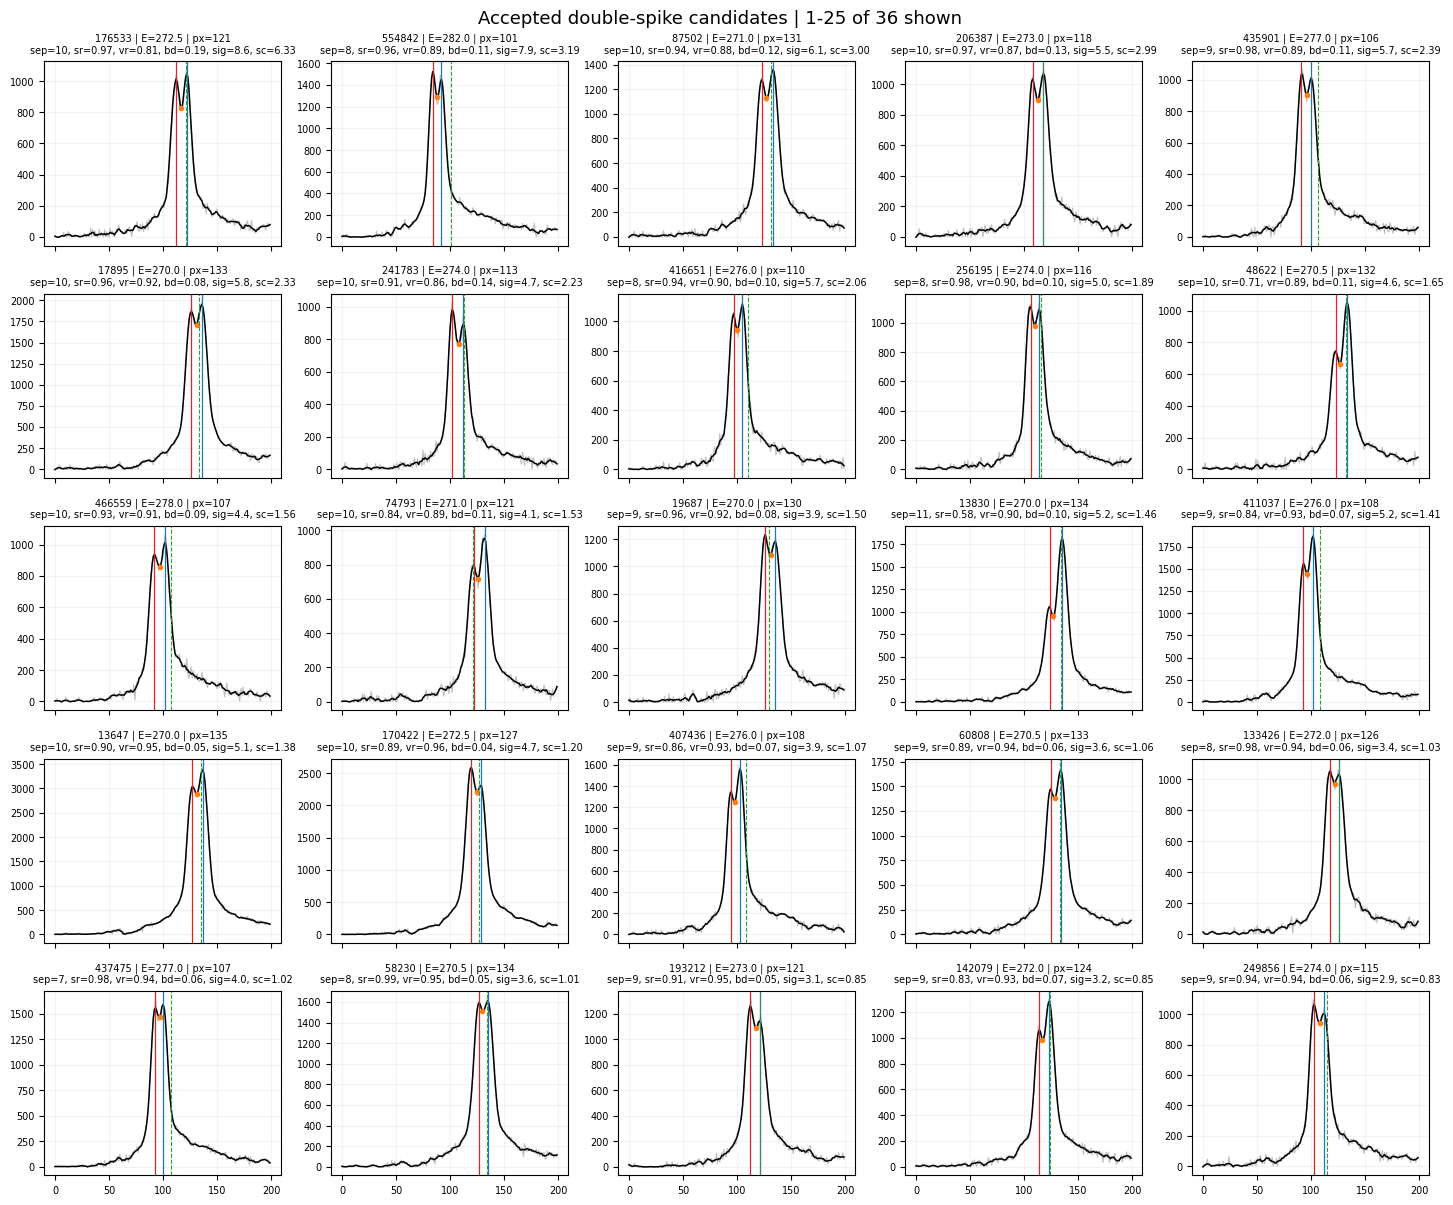

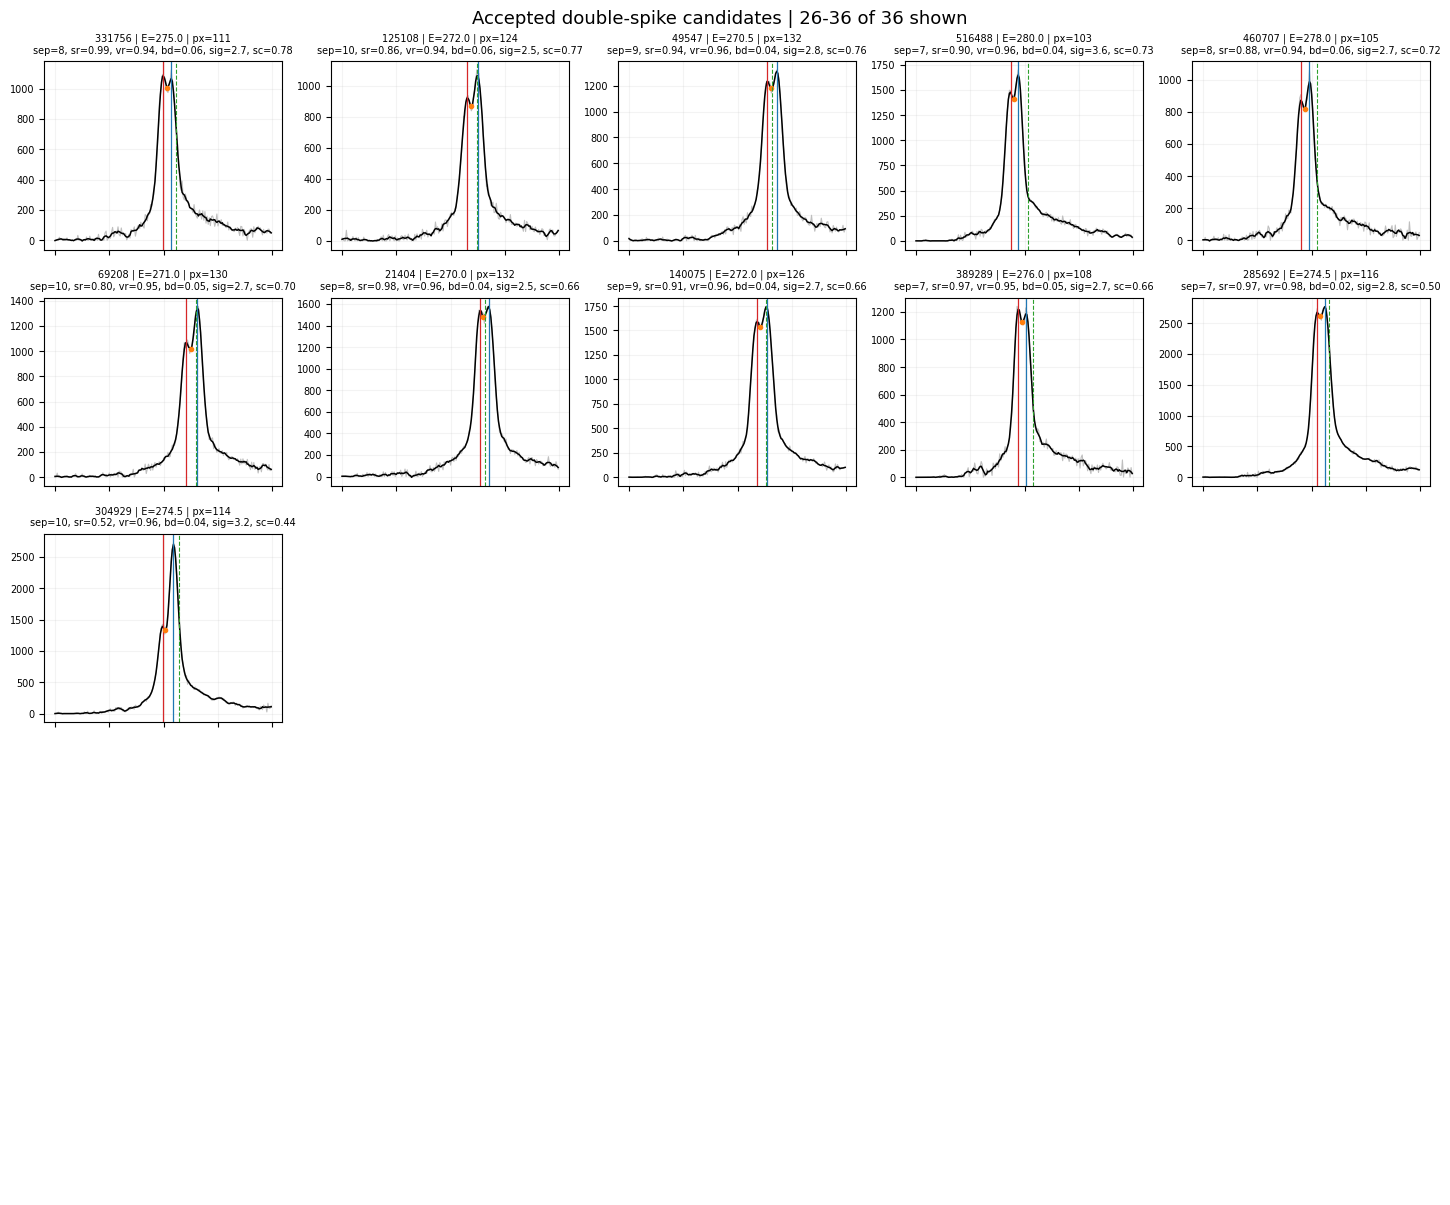

In [18]:
# --- Plot a random sample of accepted candidates ---

N_SAMPLE = 75
RANDOM_SEED = 123

accepted_idx = np.flatnonzero(ds_pairscan["is_candidate"])

rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(
    accepted_idx,
    size=min(N_SAMPLE, len(accepted_idx)),
    replace=False,
)

# Optional: sort sampled shots by score so strongest-looking sampled shots appear first
sample_idx = sample_idx[np.argsort(ds_pairscan["score"][sample_idx])[::-1]]

print(f"plotting {len(sample_idx)} random accepted candidates out of {len(accepted_idx)}")

plot_double_spike_candidate_pages(
    sample_idx,
    ds_pairscan,
    n_per_page=25,
    ncols=5,
    max_pages=3,
)

## GMD vs. integrated VLS correlation

All valid shots pooled — same diagnostic as the nominal-E notebook.

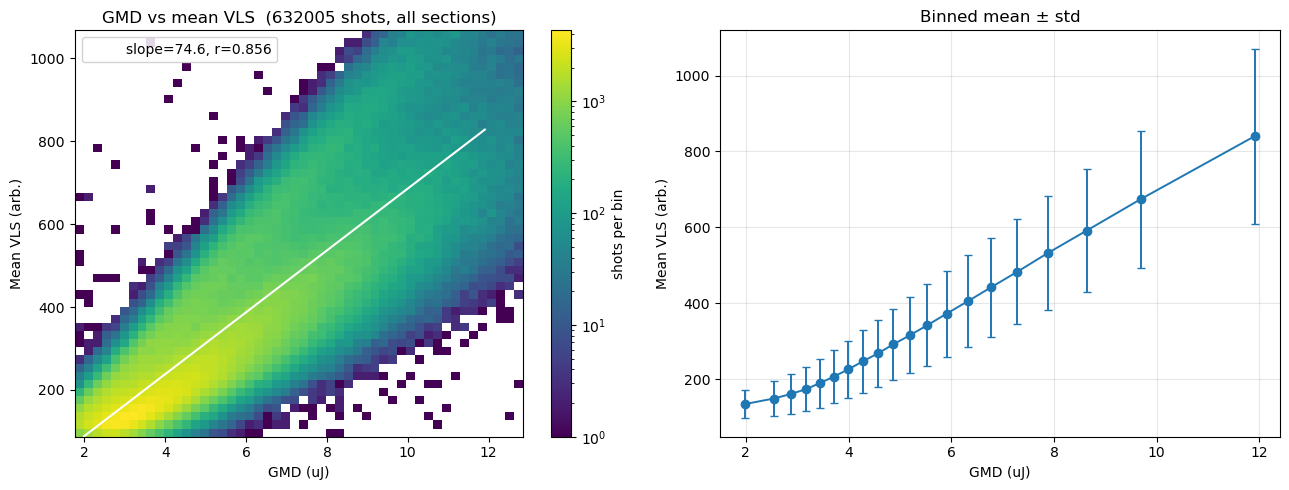

In [17]:
y_vls_mean = A_valid.mean(axis=1)

bin_edges_b = np.percentile(g_valid, np.linspace(0, 100, 21))
bin_idx_b   = np.clip(np.digitize(g_valid, bin_edges_b) - 1, 0, len(bin_edges_b) - 2)
x_mean_b = np.array([np.nanmean(g_valid[bin_idx_b == b])    if np.any(bin_idx_b == b) else np.nan
                     for b in range(len(bin_edges_b) - 1)])
y_mean_b = np.array([np.nanmean(y_vls_mean[bin_idx_b == b]) if np.any(bin_idx_b == b) else np.nan
                     for b in range(len(bin_edges_b) - 1)])
y_std_b  = np.array([np.nanstd(y_vls_mean[bin_idx_b == b])  if np.any(bin_idx_b == b) else np.nan
                     for b in range(len(bin_edges_b) - 1)])

r = float(np.corrcoef(g_valid, y_vls_mean)[0, 1])
slope, intercept = np.polyfit(g_valid, y_vls_mean, 1)
xl = np.linspace(np.nanmin(x_mean_b), np.nanmax(x_mean_b), 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
h = ax1.hist2d(
    g_valid, y_vls_mean,
    bins=[np.linspace(np.percentile(g_valid, 1),    np.percentile(g_valid, 99),    51),
          np.linspace(np.percentile(y_vls_mean, 1), np.percentile(y_vls_mean, 99), 51)],
    cmap='viridis', cmin=1, norm=mcolors.LogNorm(),
)
fig.colorbar(h[3], ax=ax1, label='shots per bin')
ax1.plot(xl, slope * xl + intercept, color='white', lw=1.5,
         label=f'slope={slope:.3g}, r={r:.3f}')
ax1.set_xlabel('GMD (uJ)')
ax1.set_ylabel('Mean VLS (arb.)')
ax1.set_title(f'GMD vs mean VLS  ({len(g_valid)} shots, all sections)')
ax1.legend(loc='upper left', framealpha=0.85)

ax2.errorbar(x_mean_b, y_mean_b, yerr=y_std_b, fmt='o-', color='tab:blue',
             capsize=3, lw=1.4)
ax2.set_xlabel('GMD (uJ)')
ax2.set_ylabel('Mean VLS (arb.)')
ax2.set_title('Binned mean ± std')
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## GMD binning per proxy energy

Accumulate sums over shots grouped by (proxy_pixel, GMD bin).

In [19]:
N_GMD = len(GMD_EDGES) - 1

A_sum     = np.zeros((N_proxy_E, N_GMD, n_pixels), dtype=np.float64)
G_sum     = np.zeros((N_proxy_E, N_GMD),           dtype=np.float64)
n_per_bin = np.zeros((N_proxy_E, N_GMD),           dtype=np.int64)

gmd_bins = np.digitize(g_valid, GMD_EDGES) - 1
in_range = (gmd_bins >= 0) & (gmd_bins < N_GMD)

pe_ir = proxy_idx[in_range]
gb_ir = gmd_bins[in_range]
G_ir  = g_valid[in_range]
A_ir  = A_valid[in_range]

np.add.at(n_per_bin, (pe_ir, gb_ir), 1)
np.add.at(G_sum,     (pe_ir, gb_ir), G_ir)
np.add.at(A_sum,     (pe_ir, gb_ir), A_ir)   # vectorised over pixels — no pixel loop needed

safe_n = np.where(n_per_bin > 0, n_per_bin, 1).astype(np.float64)
G_mean = np.where(n_per_bin > 0, G_sum / safe_n, np.nan)
A_mean = np.where(n_per_bin[:, :, None] > 0, A_sum / safe_n[:, :, None], np.nan)

print(f'unique proxy energies (pixels): {N_proxy_E}')
print(f'total shots binned            : {int(n_per_bin.sum())}')
print(f'A_mean shape                  : {A_mean.shape}')

unique proxy energies (pixels): 62
total shots binned            : 625446
A_mean shape                  : (62, 4, 200)


## Shot counts per (proxy energy, GMD bin)

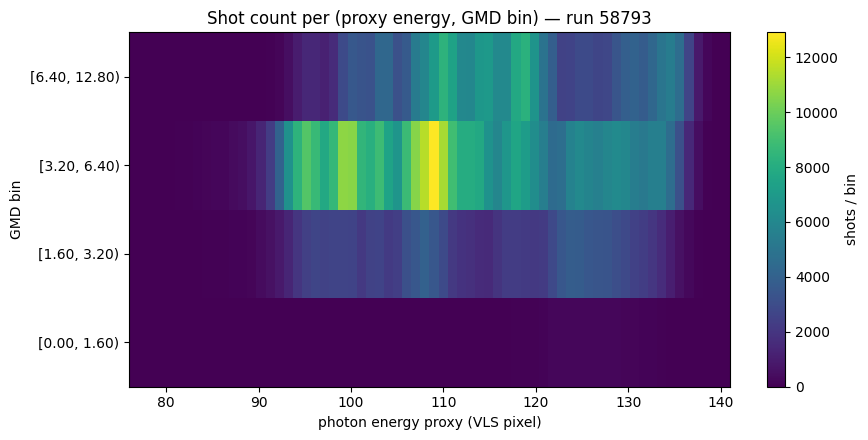

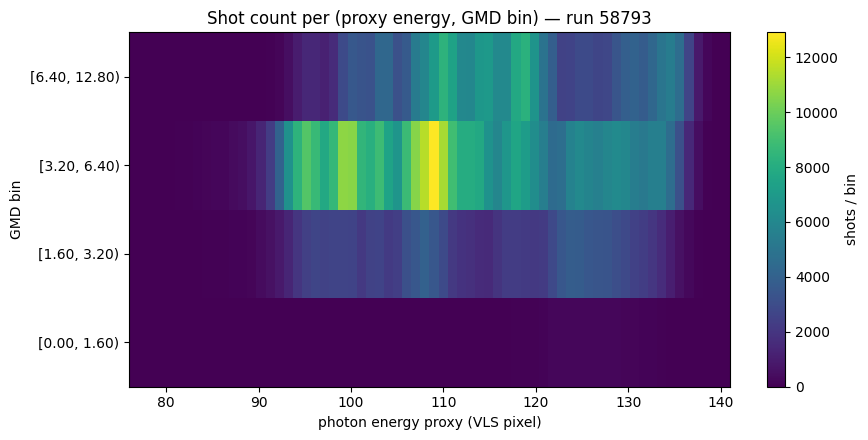

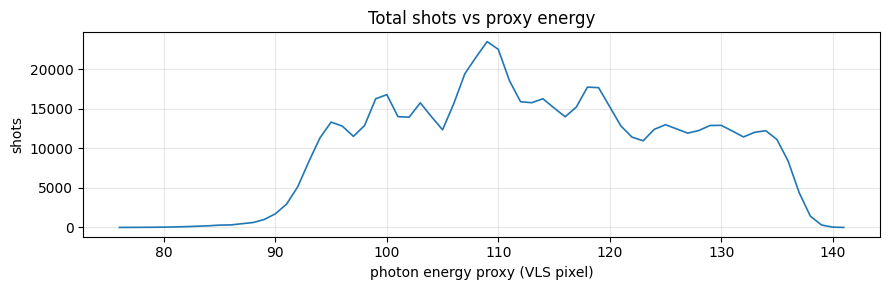

In [135]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(
    n_per_bin.T,
    aspect='auto', origin='lower',
    extent=[proxy_energies[0], proxy_energies[-1], 0, N_GMD],
    cmap='viridis',
)
fig.colorbar(im, ax=ax, label='shots / bin')
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('GMD bin')
ax.set_yticks(np.arange(N_GMD) + 0.5)
ax.set_yticklabels([f'[{GMD_EDGES[i]:.2f}, {GMD_EDGES[i+1]:.2f})' for i in range(N_GMD)])
ax.set_title(f'Shot count per (proxy energy, GMD bin) — run {RUN_NO}')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.plot(proxy_energies, n_per_bin.sum(axis=1), color='tab:blue', lw=1.2)
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('shots')
ax.set_title('Total shots vs proxy energy')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Mean GMD per (proxy energy, GMD bin)

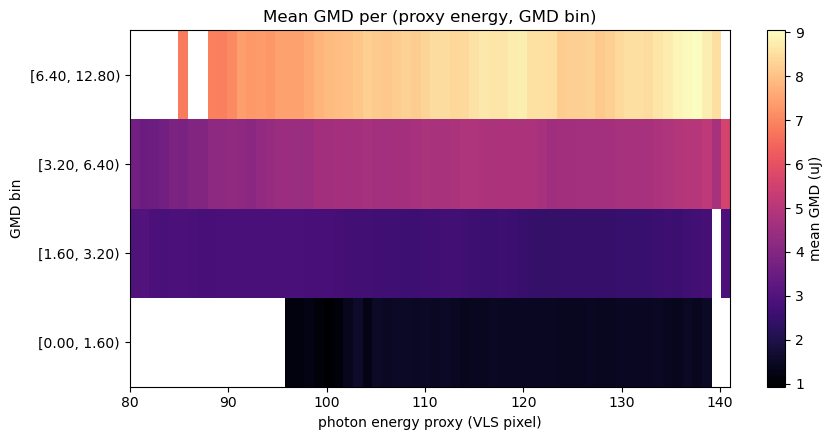

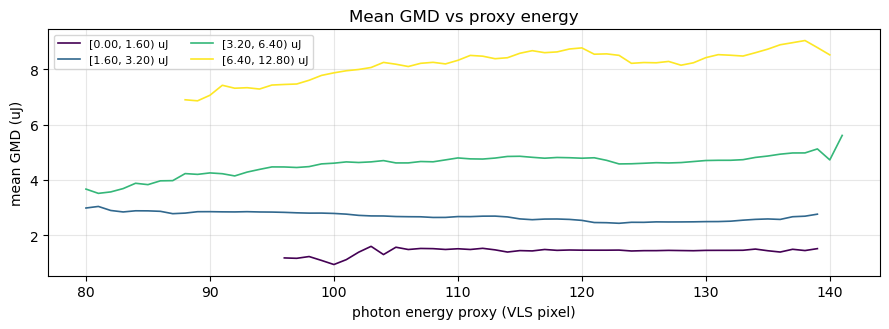

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(
    G_mean.T,
    aspect='auto', origin='lower',
    extent=[proxy_energies[0], proxy_energies[-1], 0, N_GMD],
    cmap='magma',
)
fig.colorbar(im, ax=ax, label='mean GMD (uJ)')
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('GMD bin')
ax.set_yticks(np.arange(N_GMD) + 0.5)
ax.set_yticklabels([f'[{GMD_EDGES[i]:.2f}, {GMD_EDGES[i+1]:.2f})' for i in range(N_GMD)])
ax.set_title('Mean GMD per (proxy energy, GMD bin)')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.4))
cmap = plt.get_cmap('viridis')
for g in range(N_GMD):
    ax.plot(proxy_energies, G_mean[:, g], lw=1.2,
            color=cmap(g / max(N_GMD - 1, 1)),
            label=f'[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ')
ax.set_xlabel('photon energy proxy (VLS pixel)')
ax.set_ylabel('mean GMD (uJ)')
ax.set_title('Mean GMD vs proxy energy')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Mean VLS spectrum per (proxy energy, GMD bin)

One panel per GMD bin. Each panel is a heatmap of
**proxy energy (rows) × VLS pixel (columns)**.

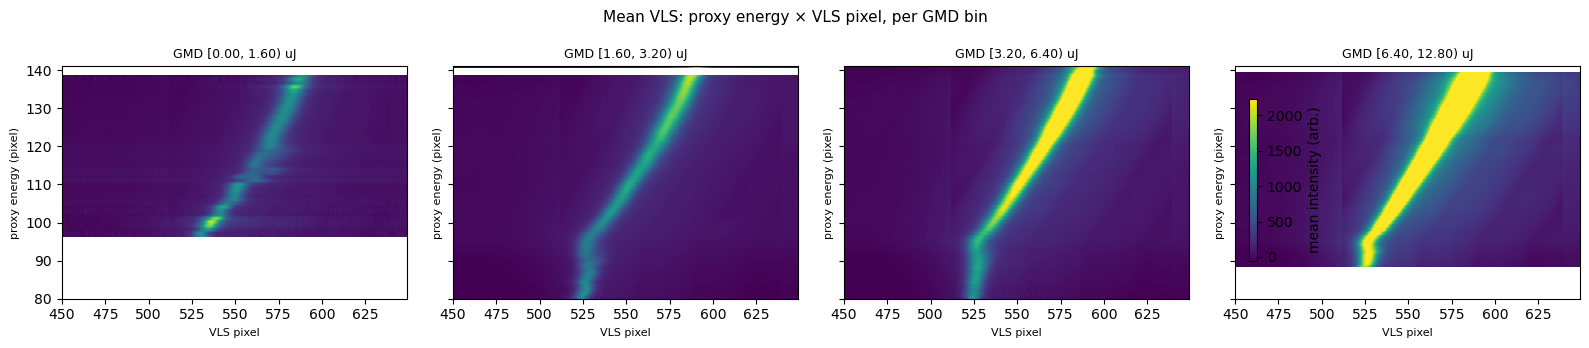

In [21]:
finite_mask = np.isfinite(A_mean)
vmin, vmax = (np.nanpercentile(A_mean[finite_mask], [2, 98])
              if finite_mask.any() else (0.0, 1.0))

ncols = min(N_GMD, 4)
nrows = int(np.ceil(N_GMD / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4.0 * ncols, 3.5 * nrows),
                         sharex=True, sharey=True, squeeze=False)
im = None
for g in range(nrows * ncols):
    r, c = divmod(g, ncols)
    ax = axes[r][c]
    if g >= N_GMD:
        ax.axis('off')
        continue
    im = ax.imshow(
        A_mean[:, g, :],             # (N_proxy_E, n_pixels)
        aspect='auto', origin='lower',
        extent=[vls_pixels[0], vls_pixels[-1],
                proxy_energies[0], proxy_energies[-1]],
        cmap='viridis', vmin=vmin, vmax=vmax,
    )
    ax.set_title(f'GMD [{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ', fontsize=9)
    ax.set_xlabel('VLS pixel', fontsize=8)
    ax.set_ylabel('proxy energy (pixel)', fontsize=8)
if im is not None:
    fig.colorbar(im, ax=axes, shrink=0.6, label='mean intensity (arb.)')
fig.suptitle('Mean VLS: proxy energy × VLS pixel, per GMD bin', fontsize=11)
fig.tight_layout()
plt.show()

## XAS(E_proxy) per GMD bin

`XAS = <GMD> / sum_pixels(<VLS>)` — one line per GMD bin,
plotted against the proxy pixel energy.

In [24]:
vls_sum = np.nansum(A_mean, axis=2)  # (N_proxy_E, N_GMD)
with np.errstate(divide='ignore', invalid='ignore'):
    xas = G_mean / vls_sum  # (N_proxy_E, N_GMD)
fig = go.Figure()
cmap = plt.get_cmap('viridis')
for g in range(N_GMD):
    color = mcolors.to_hex(cmap(g / max(N_GMD - 1, 1)))
    fig.add_trace(
        go.Scatter(
            x=proxy_energies,
            y=xas[:, g],
            mode='lines',
            name=f'[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ',
            line=dict(width=2, color=color),
            hovertemplate=(
                'GMD bin=%{fullData.name}<br>'
                'proxy pixel=%{x}<br>'
                'XAS=%{y}<extra></extra>'
            ),
        )
    )
fig.update_layout(
    title=f'Run {RUN_NO}: XAS(E_proxy) per GMD bin',
    xaxis_title='photon energy proxy (VLS pixel)',
    yaxis_title='XAS = <GMD> / sum_pix(<VLS>)',
    template='plotly_white',
    height=500,
    legend=dict(title='GMD bin'),
)
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

### Combining proxy photon energy bins

In [29]:
# --- Combine neighbouring photon-energy proxy bins before plotting XAS ---
# Set depending how aggressively you want to merge x bins.
X_BIN_WIDTH = 2

# Group consecutive proxy-energy bins together.
# Example: X_BIN_WIDTH=3 means proxy bins 0,1,2 -> one plotted x bin.
x_group = np.arange(N_proxy_E) // X_BIN_WIDTH
N_proxy_E_coarse = int(x_group.max()) + 1

A_sum_coarse = np.zeros((N_proxy_E_coarse, N_GMD, n_pixels), dtype=np.float64)
G_sum_coarse = np.zeros((N_proxy_E_coarse, N_GMD), dtype=np.float64)
n_per_bin_coarse = np.zeros((N_proxy_E_coarse, N_GMD), dtype=np.int64)

np.add.at(A_sum_coarse, x_group, A_sum)
np.add.at(G_sum_coarse, x_group, G_sum)
np.add.at(n_per_bin_coarse, x_group, n_per_bin)

safe_n = np.where(n_per_bin_coarse > 0, n_per_bin_coarse, 1).astype(np.float64)

G_mean_coarse = np.where(
    n_per_bin_coarse > 0,
    G_sum_coarse / safe_n,
    np.nan,
)

A_mean_coarse = np.where(
    n_per_bin_coarse[:, :, None] > 0,
    A_sum_coarse / safe_n[:, :, None],
    np.nan,
)

# Use the count-weighted mean proxy pixel as the x-coordinate.
counts_per_x = n_per_bin.sum(axis=1)
proxy_sum_coarse = np.zeros(N_proxy_E_coarse, dtype=np.float64)
counts_coarse = np.zeros(N_proxy_E_coarse, dtype=np.float64)

np.add.at(proxy_sum_coarse, x_group, proxy_energies * counts_per_x)
np.add.at(counts_coarse, x_group, counts_per_x)

proxy_energies_coarse = np.where(
    counts_coarse > 0,
    proxy_sum_coarse / counts_coarse,
    np.nan,
)

proxy_labels_coarse = [
    f"{proxy_energies[x_group == i][0]}-{proxy_energies[x_group == i][-1]}"
    for i in range(N_proxy_E_coarse)
]

print(f"Original proxy-energy bins: {N_proxy_E}")
print(f"Coarse proxy-energy bins  : {N_proxy_E_coarse}")
print(f"X bin width               : {X_BIN_WIDTH}")
print(f"Median shots/bin before   : {np.nanmedian(n_per_bin[n_per_bin > 0]):.1f}")
print(f"Median shots/bin after    : {np.nanmedian(n_per_bin_coarse[n_per_bin_coarse > 0]):.1f}")

# --- XAS plot using the coarser photon-energy bins ---
vls_sum_coarse = np.nansum(A_mean_coarse, axis=2)

with np.errstate(divide="ignore", invalid="ignore"):
    xas_coarse = G_mean_coarse / vls_sum_coarse

fig = go.Figure()
cmap = plt.get_cmap("viridis")

for g in range(N_GMD):
    color = mcolors.to_hex(cmap(g / max(N_GMD - 1, 1)))
    fig.add_trace(
        go.Scatter(
            x=proxy_energies_coarse,
            y=xas_coarse[:, g],
            text=proxy_labels_coarse,
            mode="lines+markers",
            name=f"[{GMD_EDGES[g]:.2f}, {GMD_EDGES[g+1]:.2f}) uJ",
            line=dict(width=2, color=color),
            marker=dict(size=5, color=color),
            hovertemplate=(
                "GMD bin=%{fullData.name}<br>"
                "proxy bin=%{text}<br>"
                "x=%{x:.2f}<br>"
                "XAS=%{y}<extra></extra>"
            ),
        )
    )

fig.update_layout(
    title=f"Run {RUN_NO}: XAS(E_proxy) per GMD bin, x bins combined by {X_BIN_WIDTH}",
    xaxis_title="photon energy proxy (VLS pixel)",
    yaxis_title="XAS = <GMD> / sum_pix(<VLS>)",
    template="plotly_white",
    height=500,
    legend=dict(title="GMD bin"),
)

display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

Original proxy-energy bins: 62
Coarse proxy-energy bins  : 31
X bin width               : 2
Median shots/bin before   : 2191.0
Median shots/bin after    : 4454.0


In [26]:
N_SHOW = 20
SHOT_STRIDE = max(1, len(A_valid) // N_SHOW)  # uniform stride
shot_indices = np.arange(0, len(A_valid), SHOT_STRIDE)[:N_SHOW]
vls_pixel_rel = np.arange(n_pixels)
fig = go.Figure()
for k, idx in enumerate(shot_indices):
    fig.add_trace(
        go.Scatter(
            x=vls_pixel_rel,
            y=A_valid[idx],
            mode='lines',
            name=(
                f'shot {idx} | E_nom={nominal_energy_valid[idx]:.2f} eV | '
                f'px={proxy_pixel[idx]} | GMD={g_valid[idx]:.2f} uJ'
            ),
            line=dict(width=2),
            opacity=0.8,
            hovertemplate=(
                'shot=%{fullData.name}<br>'
                'VLS pixel (relative)=%{x}<br>'
                'intensity=%{y}<extra></extra>'
            ),
        )
    )
fig.update_layout(
    xaxis_title='VLS pixel (relative)',
    yaxis_title='intensity (arb., bg-subtracted)',
    template='plotly_white',
    height=700,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='left',
        x=0.0,
        font=dict(size=10),
    ),
    margin=dict(t=160),
)
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))
